In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy

import sys
sys.path.append("C:/Users/siddh/Desktop/Graduate files/Research/mpemba_functions")
import mpemba
import fokker_planck

D=80

In [2]:
potential = mpemba.special_potentials.AsymmetricDoubleWellPotential(E_tilt=0.6, force_asymmetry=0.3, x_min=-10, x_max=10)

inst = mpemba.quench_methods.InstantaneousQuench()
slow = mpemba.quench_methods.ExponentialQuench(None, 1/np.abs(potential.eigs_k(D=D, k=2)[0]))
crit = mpemba.quench_methods.ExponentialQuench(None, 1/np.abs(potential.eigs_k(D=D, k=3)[0]))
fast = mpemba.quench_methods.ExponentialQuench(None, 1/np.abs(potential.eigs_k(D=D, k=4)[0]))

In [3]:
slow_ensemble = mpemba.construct_simulated_ensemble(potential, k_BTs=[10,3,1], num_particles = 10_000, quench_protocol=slow, expt_length=6e-2, gamma=1/D)
fast_ensemble = mpemba.construct_simulated_ensemble(potential, k_BTs=[10,3,1], num_particles = 10_000, quench_protocol=fast, expt_length=6e-2, gamma=1/D)

100%|██████████| 5999/5999 [00:05<00:00, 1145.14it/s]


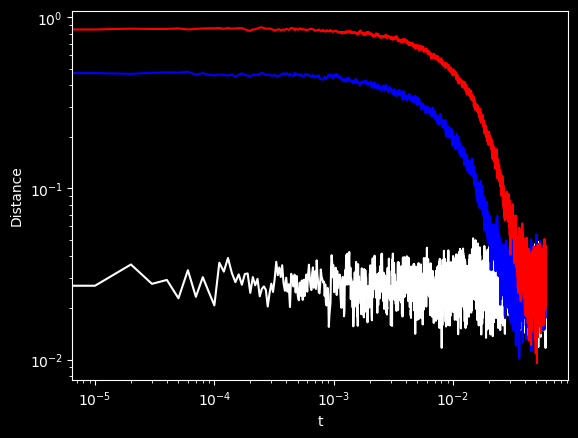

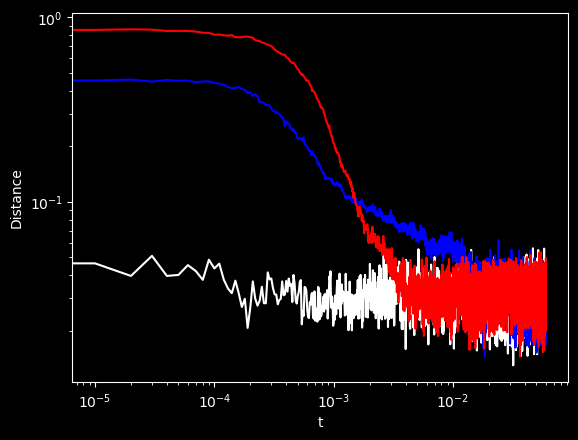

In [4]:
plt.close()
slow_ensemble.plot_distances(colors=['r','b','w'])
plt.show()
plt.close()
fast_ensemble.plot_distances(colors=['r','b','w'])
plt.show()
# plt.close()
# crit_ensemble.plot_distances(colors=['r','b','w'])

In [5]:
x = potential.mesh(500)

slow_analytic = fokker_planck.analytic_solution([12,3], potential, D=D, quench_protocol=slow, error_tolerance=4e-3, dt=5e-7)
fast_analytic = fokker_planck.analytic_solution([12,3], potential, D=D, quench_protocol=fast, error_tolerance=4e-3, dt=5e-7)

slow_dist = fokker_planck.analytical_distances_to_boltzmann(slow_analytic, potential)
fast_dist = fokker_planck.analytical_distances_to_boltzmann(fast_analytic, potential)



100%|██████████| 2/2 [00:06<00:00,  3.11s/it]


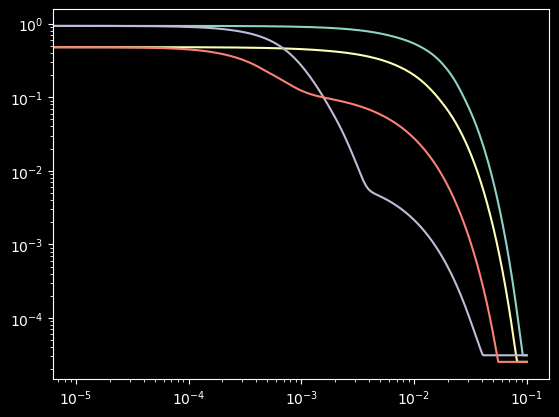

In [6]:
plt.loglog(np.arange(slow_dist.shape[1])*1e-5, slow_dist.T)
plt.loglog(np.arange(slow_dist.shape[1])*1e-5, fast_dist.T)
plt.show()

In [7]:
1/np.abs(potential.eigs_k(k=3, D=D)[0])

0.0003877013036229512

In [42]:
crit2 = mpemba.quench_methods.ExponentialQuench(None, tau=0.001445)

crit_analytic = fokker_planck.analytic_solution([12,3], potential, D=D, quench_protocol=crit2, error_tolerance=4e-3, dt=5e-7)
crit_dist = fokker_planck.analytical_distances_to_boltzmann(crit_analytic, potential)
plt.loglog(np.arange(crit_dist.shape[1])*1e-5, crit_dist.T)

  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:08<00:00,  4.05s/it]


In [52]:
0.1/crit2.tau

69.20415224913495

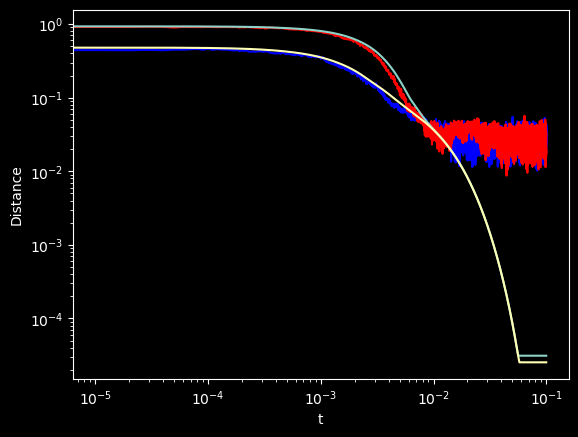

In [43]:
plt.close()
try: 
    print(crit2_ensemble)
except Exception as e:
    crit2_ensemble = mpemba.construct_simulated_ensemble(potential, k_BTs=[12,3,1], num_particles=10_000, gamma=1/D, quench_protocol=crit2)


crit2_ensemble.plot_distances()
plt.loglog(np.arange(crit_dist.shape[1])*1e-5, crit_dist.T)
plt.show()

100%|██████████| 2/2 [00:07<00:00,  3.80s/it]


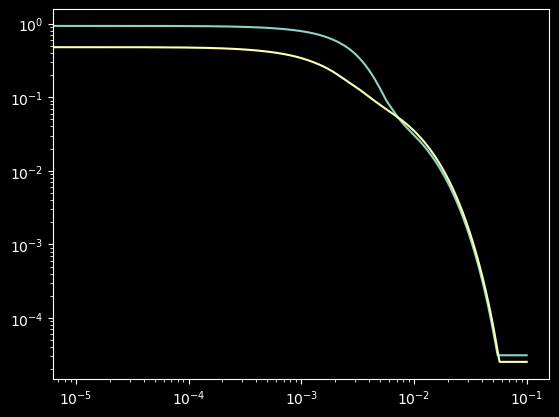

In [50]:
plt.close()
crit3 = mpemba.quench_methods.ExponentialQuench(None, tau=0.0013)

crit3_analytic = fokker_planck.analytic_solution([12,3], potential, D=D, quench_protocol=crit3, error_tolerance=4e-3, dt=5e-7)
crit3_dist = fokker_planck.analytical_distances_to_boltzmann(crit3_analytic, potential)
plt.loglog(np.arange(crit3_dist.shape[1])*1e-5, crit3_dist.T)
plt.show()

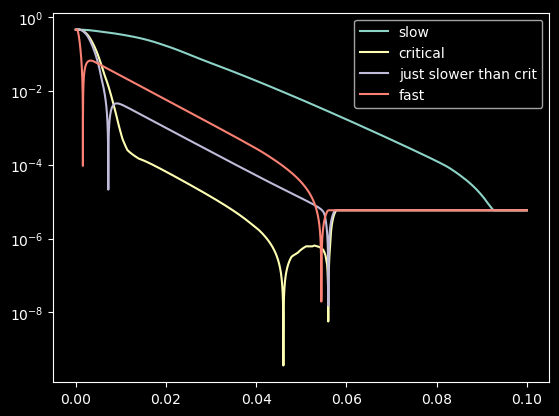

In [51]:
plt.close()
plt.semilogy(np.arange(slow_dist.shape[1])*1e-5, np.abs(slow_dist[0,:]-slow_dist[1,:]), label="slow")
plt.semilogy(np.arange(crit_dist.shape[1])*1e-5, np.abs(crit_dist[0,:]-crit_dist[1,:]), label="critical")
plt.semilogy(np.arange(crit3_dist.shape[1])*1e-5, np.abs(crit3_dist[0,:]-crit3_dist[1,:]), label="just slower than crit")
plt.semilogy(np.arange(fast_dist.shape[1])*1e-5, np.abs(fast_dist[0,:]-fast_dist[1,:]), label="fast")
# plt.xlim(0,0.04)
plt.legend()
plt.show()

In [58]:
fast_dist[:,:6001].shape

(2, 6001)

In [71]:
df = pd.DataFrame(np.array([*slow_ensemble.get_distances(), *fast_ensemble.get_distances(), *crit2_ensemble.get_distances()[:,:6000]]).T, index=fast_ensemble.times, columns=['slowh', 'sloww', 'slowc', 'fasth', 'fastw', 'fastc', 'crith', 'critw', 'critc'])
df.index.name = 't'
df.to_csv("quench_distances.csv")

In [66]:
df2 = pd.DataFrame(np.array([*slow_dist, *fast_dist, *crit_dist]).T, index=np.arange(crit_dist.shape[1])*1e-5, columns=['slowh', 'sloww', 'fasth', 'fastw', 'crith', 'critw'])
df2.index.name = 't'
df2.to_csv("quench_distances_FPE.csv")